In [26]:
import pandas as pd
import numpy as np
import math,os
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from xgboost import XGBClassifier,XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from math import sqrt
from numpy import concatenate
from matplotlib import pyplot
from pandas import read_csv
from pandas import DataFrame
from pandas import concat
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
 

2024-10-29 13:25:06.478778: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-29 13:25:06.494962: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-29 13:25:06.601660: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-29 13:25:06.670633: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1730229906.740650   17891 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1730229906.76

In [2]:
def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)
    """
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Radius of earth in kilometers. Use 3956 for miles
    return c * r

## Station Inventory

In [3]:
inv = pd.read_csv("Data/GSOM/stations.csv")

In [4]:
inv.head()

,STATION_ID,STATION,BEGIN_DATE,END_DATE,STATE,COUNTRY,LATITUDE,LONGITUDE,ELEVATION
0,GHCND:US1COAD0248,"ADENA 3.9 SW, CO US",2020-07-31,2024-09-30,Colorado,United States,39.972005,-103.931136,1502.7
1,GHCND:US1COAD0249,"ADENA 4.4 SSE, CO US",2020-08-31,2024-08-31,Colorado,United States,39.963457,-103.839581,1436.5
2,GHCND:US1COMR0073,"ADENA SCHOOL 0.6 W, CO US",2005-04-30,2006-08-31,Colorado,United States,40.116219,-103.802554,1346.0
3,GHCND:US1COEL0101,"AGATE 14.5 WSW, CO US",2021-06-30,2022-09-30,Colorado,United States,39.411667,-104.210000,1881.8
4,GHCND:US1COEL0034,"AGATE 15 W, CO US",2005-02-28,2005-06-30,Colorado,United States,39.448400,-104.221800,1836.1


In [5]:
inv.dtypes

STATION_ID     object
STATION        object
BEGIN_DATE     object
END_DATE       object
STATE          object
COUNTRY        object
LATITUDE      float64
LONGITUDE     float64
ELEVATION     float64
dtype: object

In [6]:
inv["BEGIN_DATE"] = pd.to_datetime(inv["BEGIN_DATE"])
inv["END_DATE"] = pd.to_datetime(inv["END_DATE"])



In [7]:
inv.shape

(1000, 9)

In [8]:
a = inv.loc[(inv["BEGIN_DATE"] < "1995-01-01") & (inv["END_DATE"] >  "2024-06-30")]

In [9]:
a.head()

,STATION_ID,STATION,BEGIN_DATE,END_DATE,STATE,COUNTRY,LATITUDE,LONGITUDE,ELEVATION
26,GHCND:USC00050109,"AKRON 4 E, CO US",1893-05-31,2024-09-30,Colorado,United States,40.155070,-103.141800,1384.4
32,GHCND:USW00024015,"AKRON WASHINGTON CO AIRPORT, CO US",1937-02-28,2024-09-30,Colorado,United States,40.174306,-103.214588,1428.0
43,GHCND:USW00023061,"ALAMOSA BERGMAN FIELD, CO US",1947-12-31,2024-09-30,Colorado,United States,37.439310,-105.861800,2297.4
60,GHCND:USC00050214,"ALTENBERN, CO US",1947-06-30,2024-09-30,Colorado,United States,39.499200,-108.380900,1718.2
66,GHCND:USC00050263,"ANTERO RESERVOIR, CO US",1961-05-31,2024-07-31,Colorado,United States,38.993050,-105.891450,2724.6


In [10]:
a.shape

(45, 9)

In [11]:
b=a[["LATITUDE","LONGITUDE"]]

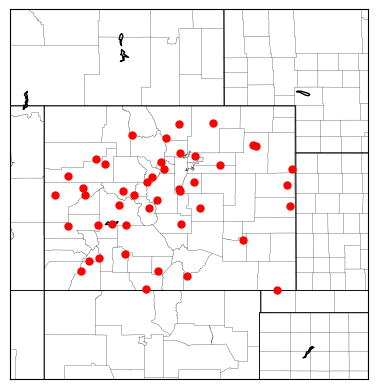

In [12]:

# Create a Basemap instance
m = Basemap(projection='merc', llcrnrlat=35, urcrnrlat=43,
            llcrnrlon=-110, urcrnrlon=-100, resolution='i')

# Draw coastlines and countries
m.drawcoastlines()
m.drawcountries()
m.drawcounties()
m.drawstates()
# Plot the points on the map
x, y = m(a.LONGITUDE.values, a.LATITUDE.values)
m.plot(x, y, 'ro', markersize=5)

plt.show()

In [13]:
b

,LATITUDE,LONGITUDE
26,40.155070,-103.141800
32,40.174306,-103.214588
43,37.439310,-105.861800
60,39.499200,-108.380900
66,38.993050,-105.891450
68,37.330000,-105.070000
76,38.852800,-102.176400
128,39.185200,-106.838000
233,40.310000,-105.640000
235,37.710000,-107.510000


In [14]:
inv.loc[(inv["BEGIN_DATE"] < "1980-01-01") ]


,STATION_ID,STATION,BEGIN_DATE,END_DATE,STATE,COUNTRY,LATITUDE,LONGITUDE,ELEVATION
5,GHCND:USC00050092,"AGATE 3 SW, CO US",1893-01-31,1953-01-31,Colorado,United States,39.450000,-103.933330,1670.9
13,GHCND:USC00050102,"AGUILAR, CO US",1979-12-31,2005-11-30,Colorado,United States,37.401100,-104.654700,1950.7
26,GHCND:USC00050109,"AKRON 4 E, CO US",1893-05-31,2024-09-30,Colorado,United States,40.155070,-103.141800,1384.4
32,GHCND:USW00024015,"AKRON WASHINGTON CO AIRPORT, CO US",1937-02-28,2024-09-30,Colorado,United States,40.174306,-103.214588,1428.0
43,GHCND:USW00023061,"ALAMOSA BERGMAN FIELD, CO US",1947-12-31,2024-09-30,Colorado,United States,37.439310,-105.861800,2297.4
...,...,...,...,...,...,...,...,...,...
960,GHCND:USW00093037,"COLORADO SPRINGS MUNICIPAL AIRPORT, CO US",1948-03-31,2024-09-30,Colorado,United States,38.809490,-104.688730,1884.2
961,GHCND:USW00093065,"COLORADO SPRINGS USAF ACADEMY, CO US",1970-07-31,1970-11-30,Colorado,United States,38.966670,-104.816670,2003.1
964,GHCND:USC00051792,"COLUMBINE, CO US",1909-09-30,1949-09-30,Colorado,United States,40.850000,-106.966670,2653.9
965,GHCND:USS0006J03S,"COLUMBINE, CO US",1979-09-30,2024-09-30,Colorado,United States,40.390000,-106.600000,2792.0


## Station Data

In [12]:
dfs = {} 
for index,row in a.iterrows():
    id = row["STATION_ID"][6:]
    lat = row["LATITUDE"]
    lon = row["LONGITUDE"]
    elv = row["ELEVATION"]
    df = pd.read_csv(f"Data/GSOM/{id}.csv")
    print(id)
    break

USC00050109


In [13]:
df

,STATION,DATE,LATITUDE,LONGITUDE,ELEVATION,NAME,AWND,AWND_ATTRIBUTES,CDSD,CDSD_ATTRIBUTES,...,SNOW,SNOW_ATTRIBUTES,TAVG,TAVG_ATTRIBUTES,TMAX,TMAX_ATTRIBUTES,TMIN,TMIN_ATTRIBUTES,WDMV,WDMV_ATTRIBUTES
0,USC00050109,1893-06,40.15507,-103.1418,1384.4,"AKRON 4 E, CO US",NaN,NaN,NaN,NaN,...,NaN,NaN,21.43,",6",29.53,",,,6",13.33,",,,6",NaN,NaN
1,USC00050109,1893-07,40.15507,-103.1418,1384.4,"AKRON 4 E, CO US",NaN,NaN,NaN,NaN,...,NaN,NaN,23.34,",6",31.34,",,,6",15.33,",,,6",NaN,NaN
2,USC00050109,1893-08,40.15507,-103.1418,1384.4,"AKRON 4 E, CO US",NaN,NaN,NaN,NaN,...,NaN,NaN,20.76,"1,6",28.89,"1,,,6",12.63,"1,,,6",NaN,NaN
3,USC00050109,1893-09,40.15507,-103.1418,1384.4,"AKRON 4 E, CO US",NaN,NaN,NaN,NaN,...,NaN,NaN,17.75,",6",27.61,",,,6",7.89,",,,6",NaN,NaN
4,USC00050109,1893-10,40.15507,-103.1418,1384.4,"AKRON 4 E, CO US",NaN,NaN,NaN,NaN,...,NaN,NaN,10.84,",6",20.92,",,,6",0.75,",,,6",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
982,USC00050109,2024-05,40.15507,-103.1418,1384.4,"AKRON 4 E, CO US",4.7,",7",1.9,NaN,...,0.0,",,,7",13.57,",7",21.48,",,,7",5.67,",,,7",6518.0,",,,7"
983,USC00050109,2024-06,40.15507,-103.1418,1384.4,"AKRON 4 E, CO US",5.2,",7",116.6,NaN,...,0.0,",,,7",21.87,",7",30.09,",,,7",13.66,",,,7",6000.0,",,,7"
984,USC00050109,2024-07,40.15507,-103.1418,1384.4,"AKRON 4 E, CO US",4.0,",7",265.2,NaN,...,0.0,",,,7",23.08,",7",31.72,",,,7",14.44,",,,7",5084.0,",,,7"
985,USC00050109,2024-08,40.15507,-103.1418,1384.4,"AKRON 4 E, CO US",3.1,",7",399.9,NaN,...,0.0,",,,7",22.35,",7",29.93,",,,7",14.76,",,,7",4787.0,",,,7"


In [17]:
df.columns

Index(['STATION', 'DATE', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'NAME', 'AWND',
       'AWND_ATTRIBUTES', 'CDSD', 'CDSD_ATTRIBUTES', 'CLDD', 'CLDD_ATTRIBUTES',
       'DP01', 'DP01_ATTRIBUTES', 'DP10', 'DP10_ATTRIBUTES', 'DP1X',
       'DP1X_ATTRIBUTES', 'DSND', 'DSND_ATTRIBUTES', 'DSNW', 'DSNW_ATTRIBUTES',
       'DT00', 'DT00_ATTRIBUTES', 'DT32', 'DT32_ATTRIBUTES', 'DX32',
       'DX32_ATTRIBUTES', 'DX70', 'DX70_ATTRIBUTES', 'DX90', 'DX90_ATTRIBUTES',
       'DYFG', 'DYFG_ATTRIBUTES', 'DYNT', 'DYNT_ATTRIBUTES', 'DYSD',
       'DYSD_ATTRIBUTES', 'DYSN', 'DYSN_ATTRIBUTES', 'DYTS', 'DYTS_ATTRIBUTES',
       'DYXP', 'DYXP_ATTRIBUTES', 'DYXT', 'DYXT_ATTRIBUTES', 'EMNT',
       'EMNT_ATTRIBUTES', 'EMSD', 'EMSD_ATTRIBUTES', 'EMSN', 'EMSN_ATTRIBUTES',
       'EMXP', 'EMXP_ATTRIBUTES', 'EMXT', 'EMXT_ATTRIBUTES', 'EVAP',
       'EVAP_ATTRIBUTES', 'HDSD', 'HDSD_ATTRIBUTES', 'HTDD', 'HTDD_ATTRIBUTES',
       'MNPN', 'MNPN_ATTRIBUTES', 'MXPN', 'MXPN_ATTRIBUTES', 'PRCP',
       'PRCP_ATTRIBUTES', 

In [19]:
a=df[["DATE","TMIN","TMAX","PRCP","EVAP"]].values
data={}
for row in a:
    date=row[0]
    data[date]={}
    data[date]["Tmin"]=float(row[1])
    data[date]["Tmax"]=float(row[2])
    data[date]["Prcp"]=float(row[3])
    data[date]["Evap"]=float(row[4])
    

In [ ]:
data

In [20]:
minCount=0
maxCount=0
pcpCount=0
evpCount=0

for year in range(1980,2024):
    for month in range(1,12):
        mon=str(month).zfill(2)
        date=f"{year}-{mon}"
        if date not in data:
            print(date)
        else:
            tmin=data[date]["Tmin"]
            tmax=data[date]["Tmax"]
            prcp=data[date]["Prcp"]
            evap=float(data[date]["Evap"])
     #       print(evap,type(evap))
            if math.isnan(tmin):
                minCount+=1
            if math.isnan(tmax):
                maxCount+=1
            if math.isnan(prcp) :
                pcpCount+=1
                
            if math.isnan(evap):
                evpCount+=1
            
print("Tmin MIss: ",minCount)
print("Tmax MIss: ",maxCount)           
print("Prcp MIss: ",pcpCount)   
print("Evap MIss: ",evpCount)           



1987-06
1992-07
Tmin MIss:  0
Tmax MIss:  0
Prcp MIss:  1
Evap MIss:  229


In [18]:
data

NameError: name 'data' is not defined

## Climate Indexes

In [15]:
indices={}
def getClimIndex(dirs):
    data={}
    misses={}
    for file in os.listdir(dirs):
        
        fin=open(f"{dirs}/{file}")
        lines=fin.readlines()
  
        line=lines[0].strip()
        spl=line.split()
        start=int(spl[0])
        end=int(spl[1])
        ee = end-start+2
        miss=float(lines[ee])
        id=lines[ee+1].split()[0]
        misses[id]=miss
        print(id,start,end,file)
        nn=0
        data[id]={}
        for year in range(start,end+1):
            nn+=1
            spl=lines[nn].split()
            if len(spl) == 13:
                year=int(spl[0])
                data[id][year]={}
                for mon in range(1,13):
                    val=float(spl[mon])
                    if val == miss:
                        val=-9999.0
                    data[id][year][mon]=val
        
    return  data,misses
clim,misses=getClimIndex("Data/GSOM/Clim")


WP 1948 2024 wp.data.txt
TNAa 1948 2024 tna.data.txt
PNA 1948 2024 pna.data.txt
EA/WR 1948 2024 ea.data.txt
Nino1+2 1948 2024 nina1.anom.data.txt
Date 1948 2024 solar.data.txt
QBO 1948 2024 qbo.data.txt
ONI 1950 2024 oni.data.txt
Nino 1948 2024 nina3.anom.data.txt
TSAa 1948 2024 tsa.data.txt
WHWPa 1948 2024 whwp.data.txt
PACWARMPOOL 1948 2024 pacwarm.data.txt
from 1950 2024 ao.data.txt
NAO 1948 2024 nao.data.txt
Nino 1948 2024 nina4.anom.data.txt
SOI 1948 2024 soi.data.txt


In [20]:
def subsetClimIndex(clim,start,end):
    climT={}
    climOrder=[]
    for key,dct in clim.items():
        climOrder.append(key)
        for year in range(start,end+1):
            for mon in range(1,13):
                mo = str(mon).zfill(2)
                date=f"{year}-{mo}"
                if date not in climT:
                    climT[date]=[]
                val=dct[year][mon]
                if val < -98:
                    print("BAD BAD ",key,year,mon,val)
                climT[date].append(val) 
    x=[]
    for date,lst in sorted(climT.items()):
        x.append(lst)
        
    return x        

X=subsetClimIndex(clim,1980,2023)   

In [17]:
len(X)

528

In [20]:
d=[]
for row in X[5:10]:
    a=X[0:5]
    d.append(a)
    
    

In [22]:
for nn,row in enumerate(d):
    print(nn,row)    

0 [[-1.71, 0.4, -1.01, 0.31, -0.25, 2062.0, -10.11, 0.59, 0.37, -0.15, -0.13, -0.278, -2.066, -1.38, 0.7], [-0.5, 0.41, 2.03, -0.3, -0.42, 2000.0, -5.65, 0.46, 0.36, -0.34, -0.18, -0.382, -0.934, -0.39, 0.5], [1.09, 0.17, -0.64, -1.42, -0.01, 1681.0, -2.9, 0.34, 0.19, -0.26, -0.59, -0.272, -1.433, -0.73, -0.7], [0.72, 0.56, 1.66, 0.3, 0.0, 2079.0, 2.31, 0.38, 0.14, -0.11, -0.13, -0.351, -0.419, 1.26, -1.0], [1.85, 0.71, -0.16, 0.24, -0.43, 2240.0, 6.24, 0.48, 0.26, -0.04, 0.95, -0.213, -1.155, -1.34, -0.0]]
1 [[-1.71, 0.4, -1.01, 0.31, -0.25, 2062.0, -10.11, 0.59, 0.37, -0.15, -0.13, -0.278, -2.066, -1.38, 0.7], [-0.5, 0.41, 2.03, -0.3, -0.42, 2000.0, -5.65, 0.46, 0.36, -0.34, -0.18, -0.382, -0.934, -0.39, 0.5], [1.09, 0.17, -0.64, -1.42, -0.01, 1681.0, -2.9, 0.34, 0.19, -0.26, -0.59, -0.272, -1.433, -0.73, -0.7], [0.72, 0.56, 1.66, 0.3, 0.0, 2079.0, 2.31, 0.38, 0.14, -0.11, -0.13, -0.351, -0.419, 1.26, -1.0], [1.85, 0.71, -0.16, 0.24, -0.43, 2240.0, 6.24, 0.48, 0.26, -0.04, 0.95, -0.2

## Machine Learning

### Train-Test

In [ ]:
data

In [21]:
def getY(data,var,start,end):
    y=[]
    for year in range(start,end+1):
        for month in range(1,13):
            mon = str(month).zfill(2)
            date=f"{year}-{mon}"
            if date in data:
                if var == "Tmin" or var == "Tmax":
                    val = float(data[date][var])*9/5+32
                y.append(val)
            else:
                print("MISSING DATE ",date)
                y.append(np.nan)
    yy=[]
    for nn,val in enumerate(y):
        if math.isnan(val):
            val=(y[nn-1]+y[nn+1])/2
            yy.append(val)
        else:
            yy.append(val)
            
    return yy
y = getY(data,"Tmax",1980,2023)

MISSING DATE  1987-06
MISSING DATE  1992-07
MISSING DATE  2002-12
MISSING DATE  2018-12


In [56]:
y[0:20]

[32.144,
 42.926,
 45.968,
 57.074,
 67.424,
 86.828,
 92.318,
 88.412,
 81.104,
 66.686,
 53.366,
 51.116,
 48.974000000000004,
 47.606,
 48.578,
 66.812,
 65.462,
 82.904,
 88.178,
 84.218]

In [47]:
for val in y:
    if math.isnan(val):
        print("Missing Val",val)

In [90]:
def splitTrainTest(X,y):
    nl=len(X)
    ss = int(nl*.8)
    xTrain = X[:ss]
    xTest = X[ss:]
    yTrain = y[:ss]
    yTest = y[ss:]
    return xTrain,xTest,yTrain,yTest

xTrain,xTest,yTrain,yTest = splitTrainTest(X,y)

### XGBoost

In [47]:
model = XGBRegressor()
model.fit(xTrain, yTrain)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [48]:
# make predictions for test data
y_pred = model.predict(xTest)

In [49]:
yDiff=[]
for nn,val in enumerate(yTest):
    diff=abs(val-y_pred[nn])
    yDiff.append(diff)

In [50]:
sum(yDiff)/len(yDiff)

6.959746566628513

### Forecast

In [23]:
def phase(X,y,np):

    yNew = y[np:]
    XNew = X[:-np]
    return XNew,yNew

# xP,yP = phase(X,y,6)
# xTrainP,xTestP,yTrainP,yTestP = splitTrainTest(xP,yP)


In [92]:
model = XGBRegressor()
model.fit(xTrainP, yTrainP)
y_predP = model.predict(xTestP)
yDiff=[]
for nn,val in enumerate(yTestP):
    diff=abs(val-y_predP[nn])
    yDiff.append(diff)
sum(yDiff)/len(yDiff)


6.627016511372161

### LSTM Window

In [32]:
def addWindow(x,y,win):
    xNew=[]
    yNew=[]
    for nn in range(win,len(x)):
        xNew.append(x[nn-win:nn])
        yNew.append(y[nn])
    return np.array(xNew),np.array(yNew)

def phase(X,y,np):

    yNew = y[np:]
    XNew = X[:-np]
    return XNew,yNew
    
def splitTrainTest(X,y):
    nl=len(X)
    ss = int(nl*.8)
    xTrain = X[:ss]
    xTest = X[ss:]
    yTrain = y[:ss]
    yTest = y[ss:]
    return xTrain,xTest,yTrain,yTest


In [41]:
Xnew,ynew = phase(X,y,1)
ynew=np.array(ynew).reshape(-1,1)

scaler = MinMaxScaler(feature_range=(0, 1))
XScaled = scaler.fit_transform(Xnew)
yScaled = scaler.fit_transform(ynew)
Xnew,yNew = addWindow(XScaled,yScaled,48)

train_X,test_X,train_y,test_y = splitTrainTest(Xnew,yNew)
model = Sequential()
model.add(LSTM(100, input_shape=(train_X.shape[1], train_X.shape[2])))
model.add(Dense(1))
model.compile(loss='mae', optimizer='adam')
# fit network
history = model.fit(train_X, train_y, epochs=50, batch_size=72, validation_data=(test_X, test_y), verbose=2, shuffle=False)
# plot history
# pyplot.plot(history.history['loss'], label='train')
# pyplot.plot(history.history['val_loss'], label='test')
# pyplot.legend()
# pyplot.show()
yhat = model.predict(test_X)

Epoch 1/50


/home/joe/anaconda3/envs/fire/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 2s - 274ms/step - loss: 0.3686 - val_loss: 0.3334
Epoch 2/50
6/6 - 0s - 35ms/step - loss: 0.2435 - val_loss: 0.2224
Epoch 3/50
6/6 - 0s - 41ms/step - loss: 0.2288 - val_loss: 0.2187
Epoch 4/50
6/6 - 0s - 39ms/step - loss: 0.2166 - val_loss: 0.2338
Epoch 5/50
6/6 - 0s - 36ms/step - loss: 0.2181 - val_loss: 0.2236
Epoch 6/50
6/6 - 0s - 37ms/step - loss: 0.2147 - val_loss: 0.2152
Epoch 7/50
6/6 - 0s - 40ms/step - loss: 0.2130 - val_loss: 0.2199
Epoch 8/50
6/6 - 0s - 36ms/step - loss: 0.2127 - val_loss: 0.2216
Epoch 9/50
6/6 - 0s - 38ms/step - loss: 0.2119 - val_loss: 0.2126
Epoch 10/50
6/6 - 0s - 36ms/step - loss: 0.2103 - val_loss: 0.2136
Epoch 11/50
6/6 - 0s - 36ms/step - loss: 0.2094 - val_loss: 0.2147
Epoch 12/50
6/6 - 0s - 39ms/step - loss: 0.2091 - val_loss: 0.2102
Epoch 13/50
6/6 - 0s - 40ms/step - loss: 0.2072 - val_loss: 0.2121
Epoch 14/50
6/6 - 0s - 39ms/step - loss: 0.2065 - val_loss: 0.2089
Epoch 15/50
6/6 - 0s - 35ms/step - loss: 0.2047 - val_loss: 0.2083
Epoch 16/50
6/

In [40]:
yhat = scaler.inverse_transform(yhat)
test_y = scaler.inverse_transform(test_y)
diff=[]
for nn,val in enumerate(test_y):
   #  print(val[0],yhat[nn][0])
     diff.append(abs(val[0]-yhat[nn][0]))
print(sum(diff)/len(diff))

12.412386710602107


In [ ]:
yhat

In [107]:
train_X[0].shape

(4, 15)

[63.572] [58.545242]
[64.004] [63.374836]
[82.67] [64.37388]
[88.61] [58.90981]
[88.556] [56.688847]
[85.622] [54.276234]
[70.394] [55.16613]
[53.366] [51.038784]
[40.802] [45.96164]
[43.25] [41.67735]
[48.524] [42.16743]
[58.712] [47.663246]
[61.502] [53.86171]
[66.938] [54.916412]
[86.594] [59.907932]
[89.618] [65.09213]
[86.45] [65.92293]
[81.428] [66.840965]
[75.488] [64.03423]
[61.34] [65.116295]
[39.38] [65.1202]
[38.858] [63.055187]
[54.194] [61.24277]
[62.564] [66.329414]
[62.816] [69.11678]
[69.08] [67.70901]
[84.236] [69.00579]
[93.074] [72.99815]
[85.604] [75.69505]
[80.546] [75.61492]
[66.074] [66.1165]
[59.936] [61.554996]
[45.41] [62.204372]
[45.932] [60.89405]
[41.324] [59.11925]
[58.946] [58.70423]
[59.072] [60.82906]
[74.03] [65.61539]
[86.936] [67.545906]
[88.52] [71.873314]
[86.252] [69.29686]
[84.182] [66.00894]
[61.88] [60.510345]
[51.26] [52.67151]
[46.94] [46.417515]
[42.62] [45.7354]
[36.23] [55.172375]
[46.112] [63.701912]
[62.726] [65.784096]
[63.122] [64.2259

In [143]:
sum(diff)/len(diff)

13.15356422816685

## Extra

In [79]:
from math import sqrt
from numpy import concatenate
from matplotlib import pyplot
from pandas import read_csv
from pandas import DataFrame
from pandas import concat
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
 
# convert series to supervised learning
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
	n_vars = 1 if type(data) is list else data.shape[1]
	df = DataFrame(data)
	cols, names = list(), list()
	# input sequence (t-n, ... t-1)
	for i in range(n_in, 0, -1):
		cols.append(df.shift(i))
		names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
	# forecast sequence (t, t+1, ... t+n)
	for i in range(0, n_out):
		cols.append(df.shift(-i))
		if i == 0:
			names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
		else:
			names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
	# put it all together
	agg = concat(cols, axis=1)
	agg.columns = names
	# drop rows with NaN values
	if dropnan:
		agg.dropna(inplace=True)
	return agg
 
# load dataset
dataset = read_csv('pollution.csv', header=0, index_col=0)
values = dataset.values
print(values[0])
# integer encode direction
encoder = LabelEncoder()
values[:,4] = encoder.fit_transform(values[:,4])
# ensure all data is float

values = values.astype('float32')
# normalize features
##scaler = MinMaxScaler(feature_range=(0, 1))
##scaled = scaler.fit_transform(values)
# specify the number of lag hours
n_hours = 3
n_features = 8
# frame as supervised learning
#reframed = series_to_supervised(scaled, n_hours, 1)
reframed = series_to_supervised(values, n_hours, 1)

print(reframed.shape)
 
# split into train and test sets
values = reframed.values
n_train_hours = 365 * 24
train = values[:n_train_hours, :]
test = values[n_train_hours:, :]
# split into input and outputs
n_obs = n_hours * n_features
train_X, train_y = train[:, :n_obs], train[:, -n_features]
test_X, test_y = test[:, :n_obs], test[:, -n_features]
print(train_X.shape, len(train_X), train_y.shape)
# reshape input to be 3D [samples, timesteps, features]
train_X = train_X.reshape((train_X.shape[0], n_hours, n_features))
test_X = test_X.reshape((test_X.shape[0], n_hours, n_features))
print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)
 

[129.0 -16 -4.0 1020.0 'SE' 1.79 0 0]
(43797, 32)
(8760, 24) 8760 (8760,)
(8760, 3, 8) (8760,) (35037, 3, 8) (35037,)


In [80]:
reframed

,var1(t-3),var2(t-3),var3(t-3),var4(t-3),var5(t-3),var6(t-3),var7(t-3),var8(t-3),var1(t-2),var2(t-2),...,var7(t-1),var8(t-1),var1(t),var2(t),var3(t),var4(t),var5(t),var6(t),var7(t),var8(t)
3,129.0,-16.0,-4.0,1020.0,2.0,1.790000,0.0,0.0,148.0,-15.0,...,0.0,0.0,181.0,-7.0,-5.0,1022.0,2.0,5.360000,1.0,0.0
4,148.0,-15.0,-4.0,1020.0,2.0,2.680000,0.0,0.0,159.0,-11.0,...,1.0,0.0,138.0,-7.0,-5.0,1022.0,2.0,6.250000,2.0,0.0
5,159.0,-11.0,-5.0,1021.0,2.0,3.570000,0.0,0.0,181.0,-7.0,...,2.0,0.0,109.0,-7.0,-6.0,1022.0,2.0,7.140000,3.0,0.0
6,181.0,-7.0,-5.0,1022.0,2.0,5.360000,1.0,0.0,138.0,-7.0,...,3.0,0.0,105.0,-7.0,-6.0,1023.0,2.0,8.930000,4.0,0.0
7,138.0,-7.0,-5.0,1022.0,2.0,6.250000,2.0,0.0,109.0,-7.0,...,4.0,0.0,124.0,-7.0,-5.0,1024.0,2.0,10.720000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43795,8.0,-23.0,0.0,1032.0,1.0,214.089996,0.0,0.0,9.0,-22.0,...,0.0,0.0,8.0,-23.0,-2.0,1034.0,1.0,231.970001,0.0,0.0
43796,9.0,-22.0,-1.0,1033.0,1.0,221.240005,0.0,0.0,10.0,-22.0,...,0.0,0.0,10.0,-22.0,-3.0,1034.0,1.0,237.779999,0.0,0.0
43797,10.0,-22.0,-2.0,1033.0,1.0,226.160004,0.0,0.0,8.0,-23.0,...,0.0,0.0,10.0,-22.0,-3.0,1034.0,1.0,242.699997,0.0,0.0
43798,8.0,-23.0,-2.0,1034.0,1.0,231.970001,0.0,0.0,10.0,-22.0,...,0.0,0.0,8.0,-22.0,-4.0,1034.0,1.0,246.720001,0.0,0.0


In [82]:
train_X[0]

array([[ 129.  ,  -16.  ,   -4.  , 1020.  ,    2.  ,    1.79,    0.  ,
           0.  ],
       [ 148.  ,  -15.  ,   -4.  , 1020.  ,    2.  ,    2.68,    0.  ,
           0.  ],
       [ 159.  ,  -11.  ,   -5.  , 1021.  ,    2.  ,    3.57,    0.  ,
           0.  ]], dtype=float32)

In [84]:
train_y[0:5]

array([181., 138., 109., 105., 124.], dtype=float32)

In [70]:
from pandas import read_csv
from datetime import datetime
# load data
def parse(x):
	return datetime.strptime(x, '%Y %m %d %H')
dataset = read_csv('raw.csv',  parse_dates = [['year', 'month', 'day', 'hour']], index_col=0, date_parser=parse)
dataset.drop('No', axis=1, inplace=True)
# manually specify column names
dataset.columns = ['pollution', 'dew', 'temp', 'press', 'wnd_dir', 'wnd_spd', 'snow', 'rain']
dataset.index.name = 'date'
# mark all NA values with 0
dataset['pollution'].fillna(0, inplace=True)
# drop the first 24 hours
dataset = dataset[24:]
# summarize first 5 rows
print(dataset.head(5))
# save to file
dataset.to_csv('pollution.csv')

/tmp/ipykernel_6294/1621407772.py:6: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  dataset = read_csv('raw.csv',  parse_dates = [['year', 'month', 'day', 'hour']], index_col=0, date_parser=parse)
/tmp/ipykernel_6294/1621407772.py:6: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  dataset = read_csv('raw.csv',  parse_dates = [['year', 'month', 'day', 'hour']], index_col=0, date_parser=parse)


                     pollution  dew  temp   press wnd_dir  wnd_spd  snow  rain
date                                                                          
2010-01-02 00:00:00      129.0  -16  -4.0  1020.0      SE     1.79     0     0
2010-01-02 01:00:00      148.0  -15  -4.0  1020.0      SE     2.68     0     0
2010-01-02 02:00:00      159.0  -11  -5.0  1021.0      SE     3.57     0     0
2010-01-02 03:00:00      181.0   -7  -5.0  1022.0      SE     5.36     1     0
2010-01-02 04:00:00      138.0   -7  -5.0  1022.0      SE     6.25     2     0


/tmp/ipykernel_6294/1621407772.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['pollution'].fillna(0, inplace=True)


In [67]:
trainX

array([[0.01544401, 0.02702703, 0.05405405],
       [0.02702703, 0.05405405, 0.04826255],
       [0.05405405, 0.04826255, 0.03281853],
       [0.04826255, 0.03281853, 0.05984557],
       [0.03281853, 0.05984557, 0.08494207],
       [0.05984557, 0.08494207, 0.08494207],
       [0.08494207, 0.08494207, 0.06177607],
       [0.08494207, 0.06177607, 0.02895753],
       [0.06177607, 0.02895753, 0.        ],
       [0.02895753, 0.        , 0.02702703],
       [0.        , 0.02702703, 0.02123553],
       [0.02702703, 0.02123553, 0.04247104],
       [0.02123553, 0.04247104, 0.07142857],
       [0.04247104, 0.07142857, 0.05984557],
       [0.07142857, 0.05984557, 0.04054055],
       [0.05984557, 0.04054055, 0.08687258],
       [0.04054055, 0.08687258, 0.12741312],
       [0.08687258, 0.12741312, 0.12741312],
       [0.12741312, 0.12741312, 0.10424709],
       [0.12741312, 0.10424709, 0.05598456],
       [0.10424709, 0.05598456, 0.01930502],
       [0.05598456, 0.01930502, 0.06949806],
       [0.

In [68]:
trainY

array([0.04826255, 0.03281853, 0.05984557, 0.08494207, 0.08494207,
       0.06177607, 0.02895753, 0.        , 0.02702703, 0.02123553,
       0.04247104, 0.07142857, 0.05984557, 0.04054055, 0.08687258,
       0.12741312, 0.12741312, 0.10424709, 0.05598456, 0.01930502,
       0.06949806, 0.07915059, 0.08880308, 0.14285713, 0.11389962,
       0.13127413, 0.14285713, 0.18339768, 0.18339768, 0.15444016,
       0.11196911, 0.08108109, 0.1196911 , 0.12934363, 0.14671814,
       0.17181468, 0.14864865, 0.15250966, 0.22007722, 0.24324325,
       0.26640925, 0.2027027 , 0.16795367, 0.13127413, 0.17374519,
       0.17760617, 0.17760617, 0.25482625, 0.25289574, 0.24131274,
       0.26833975, 0.3088803 , 0.32432434, 0.25675675, 0.20656371,
       0.14671814, 0.18725869, 0.19305018, 0.16216215, 0.25289574,
       0.23745173, 0.25096524, 0.3088803 , 0.38223937, 0.36486486,
       0.2992278 , 0.24131274, 0.1911197 , 0.24131274, 0.26640925,
       0.24903473, 0.31467178, 0.3185328 , 0.32046333, 0.40733

In [63]:
! pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 MB 10.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 26.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 25.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 23.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 26.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 24.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.3/106.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 27.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 17.8 MB/s eta

In [35]:
latlons = pd.read_csv("latLons.csv")


In [49]:
for index,ll in latlons.iterrows():
   # print(ll)
    lat=float(ll[0])
    lon=float(ll[1])
    glat=float(b[0][0])
    glon=float(b[0][1])
    mindist =  haversine(lat,lon,glat,glon)
    for gll in b:
        glat=gll[0]
        glon=gll[1]
        dist = haversine(lat,lon,glat,glon)
        if dist < mindist:
           mindist=dist
           tlat=glat
           tlon=glon
            
    print(lat,lon,mindist,glat,glon)

40.15731379530128 251.2496501305483 79.68969869436776 40.39 -106.6
40.15731379530128 252.1871488250653 35.768604287446976 40.39 -106.6
40.15731379530128 253.12464751958225 34.85887897850299 40.39 -106.6
40.15731379530128 254.0621462140992 41.9463628828457 40.39 -106.6
40.15731379530128 254.9996449086162 27.69400011646276 40.39 -106.6
40.15731379530128 255.9371436031332 46.659952836525704 40.39 -106.6
40.15731379530128 256.8746422976501 1.4194496195550124 40.39 -106.6
40.15731379530128 257.8121409921671 55.97202924875994 40.39 -106.6
39.2124374010912 251.2496501305483 12.44002913271669 40.39 -106.6
39.2124374010912 252.1871488250653 12.837539224709232 40.39 -106.6
39.2124374010912 253.12464751958225 61.45365882059234 40.39 -106.6
39.2124374010912 254.0621462140992 24.72119899092151 40.39 -106.6
39.2124374010912 254.9996449086162 22.64444222541766 40.39 -106.6
39.2124374010912 255.9371436031332 58.99206823413146 40.39 -106.6
39.2124374010912 256.8746422976501 75.15794547311963 40.39 -106

/tmp/ipykernel_29786/3230726085.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lat=float(ll[0])
/tmp/ipykernel_29786/3230726085.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lon=float(ll[1])
